<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/01_2_Exploratory_Data_Analysis_ISOT_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: Exploratory Data Analysis (EDA) - ISOT Dataset
# =================================================================

# 1. INSTALLATION AND LOADING OF LIBRARIES
# -----------------------------------------------------------------
print(" Installing and loading libraries...")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import re

warnings.filterwarnings('ignore')

In [ ]:
# 2. DATA LOADING (From Google Drive)
# -----------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ADJUST THESE PATHS to your actual CSV locations in Drive
path_true = "/content/drive/MyDrive/Project_IA/data/True.csv"
path_fake = "/content/drive/MyDrive/Project_IA/data/Fake.csv"

df_true = pd.read_csv(path_true)
df_fake = pd.read_csv(path_fake)

# Assign labels (0: Real, 1: Fake)
df_true['label'] = 0
df_fake['label'] = 1

# Merge into a single dataset
df_isot = pd.concat([df_true, df_fake]).reset_index(drop=True)
print(f"ISOT Dataset loaded successfully with {len(df_isot)} rows.")

In [ ]:
# -----------------------------------------------------------------
# 3. REUTERS SOURCE BIAS REMOVAL
# -----------------------------------------------------------------
# Real news in ISOT almost always starts with "WASHINGTON (Reuters) -"
# or similar. We must remove this so BERT doesn't "cheat" by just
# looking for the word "Reuters".

def remove_reuters_bias(text):
    # Regex pattern to match "CITY (Reuters) -" or "CITY - " at the start
    pattern = r'^.*?\(Reuters\)\s*-\s*|^.*?\s*-\s*'
    return re.sub(pattern, '', text, count=1)

print("Cleaning source bias from real news...")
df_isot['text_clean'] = df_isot['text'].apply(remove_reuters_bias)

In [ ]:
# 4. CLASS BALANCE ANALYSIS
plt.figure(figsize=(6, 4))
sns.countplot(data=df_isot, x='label', palette='magma')
plt.title('ISOT Class Distribution (0: Real, 1: Fake)')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.show()

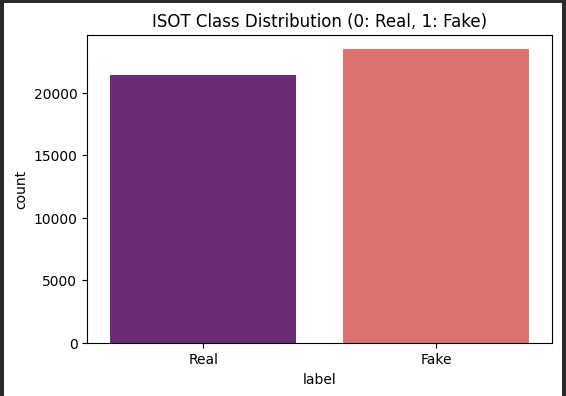

In [ ]:
# 5. TEXT LENGTH ANALYSIS (Body text)
# We analyze the "cleaned" text to see the true distribution
df_isot['text_len'] = df_isot['text_clean'].apply(len)

plt.figure(figsize=(10, 6))
# We limit to 5000 chars for better visualization of the main distribution
sns.histplot(data=df_isot[df_isot['text_len'] < 5000], x='text_len', hue='label', kde=True, palette='magma')

plt.title('News Body Length Distribution (ISOT)')
plt.xlabel('Number of Characters')
plt.show()

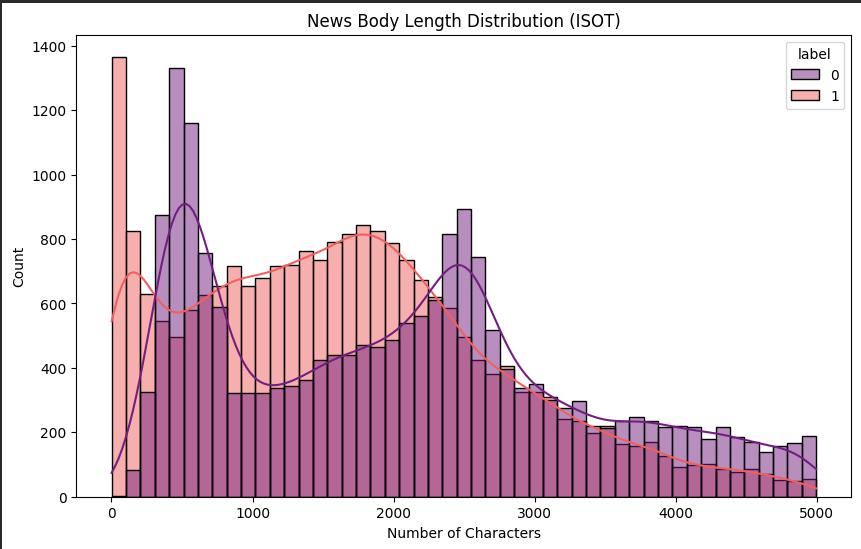

The length distribution analysis of the ISOT dataset reveals a significant structural bias between classes. Real news articles (Label 0), primarily sourced from Reuters, exhibit a consistent and multi-modal distribution with a prominent peak around 500 characters, reflecting standardized journalistic reporting. In contrast, fake news articles (Label 1) show a massive concentration of extremely short texts (under 200 characters).

This disparity suggests that the model may rely on document length as a heuristic shortcut for classification—associating brevity with misinformation—rather than performing a deep semantic evaluation of the content. Consequently, this leads to potential overfitting, where the model struggles to generalize when faced with modern, long-form fake news or concise, legitimate breaking news updates from 2026.

In [ ]:
# 6. WORDCLOUDS FOR ISOT
def generate_isot_cloud(label, title, cmap):
    # Analyzing titles for better keyword visibility
    text = " ".join(df_isot[df_isot['label'] == label]['title'])
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

generate_isot_cloud(0, "Most Frequent Words in REAL News (ISOT)", "GnBu")
generate_isot_cloud(1, "Most Frequent Words in FAKE News (ISOT)", "OrRd")

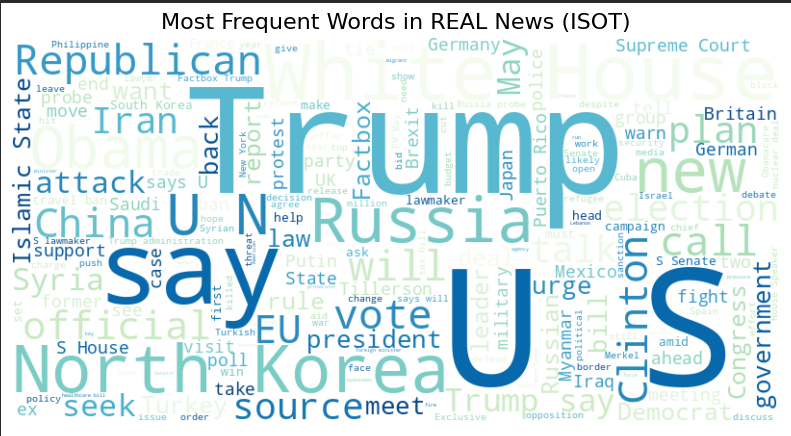

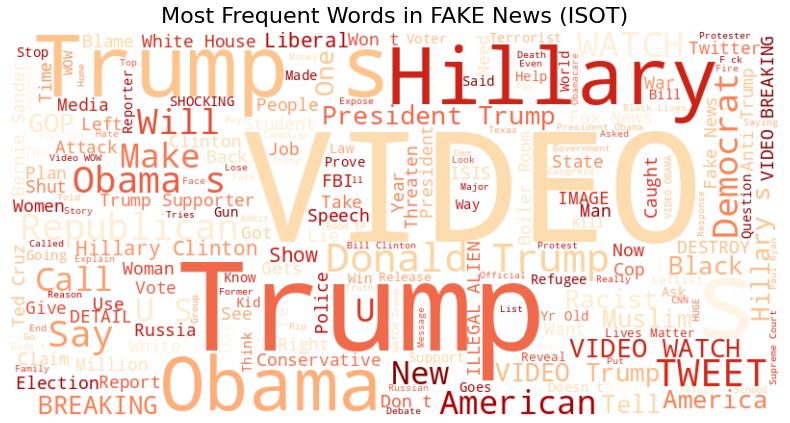

In [ ]:
# 7. KEYWORD BIAS SEARCH
def check_isot_term(term):
    # Search in the ORIGINAL text to prove the bias exists
    subset = df_isot[df_isot['text'].str.contains(term, case=False, na=False)]
    if not subset.empty:
        dist = subset['label'].value_counts(normalize=True) * 100
        print(f"\nThe term '{term}' appears in {len(subset)} articles.")
        print(f"Distribution: {dist.to_dict()}")
    else:
        print(f"\nThe term '{term}' was not found.")

# Testing the bias theories
check_isot_term("Reuters")
check_isot_term("Trump")
check_isot_term("video")
check_isot_term("say")
check_isot_term("russia")
check_isot_term("Clinton")

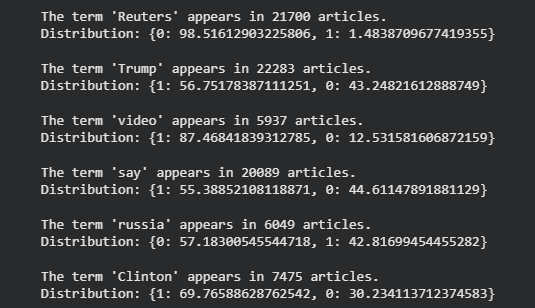

In [ ]:
# =================================================================
# 8. VALIDATION: Original Text vs. Cleaned Text
# =================================================================

def validate_cleaning(terms):
    results = []

    for term in terms:
        # Count in Original Column
        orig_count = df_isot['text'].str.contains(term, case=False, na=False).sum()
        # Count in Cleaned Column
        clean_count = df_isot['text_clean'].str.contains(term, case=False, na=False).sum()

        results.append({
            "Term": term,
            "Original Mentions": orig_count,
            "Cleaned Mentions": clean_count,
            "Removed": orig_count - clean_count
        })

    # Create a small dataframe to show results as a table
    df_validation = pd.DataFrame(results)
    print("\n --- Cleaning Validation Report ---")
    display(df_validation)

    # Visual comparison
    df_validation.set_index('Term')[['Original Mentions', 'Cleaned Mentions']].plot(kind='bar', figsize=(10, 5))
    plt.title('Effect of Bias Removal: Original vs Cleaned Column')
    plt.ylabel('Number of Mentions')
    plt.xticks(rotation=0)
    plt.show()

# List of terms to check
validate_cleaning(["Reuters","Trump", "video", "say", "russia", "Washington", "London", "Editor"])

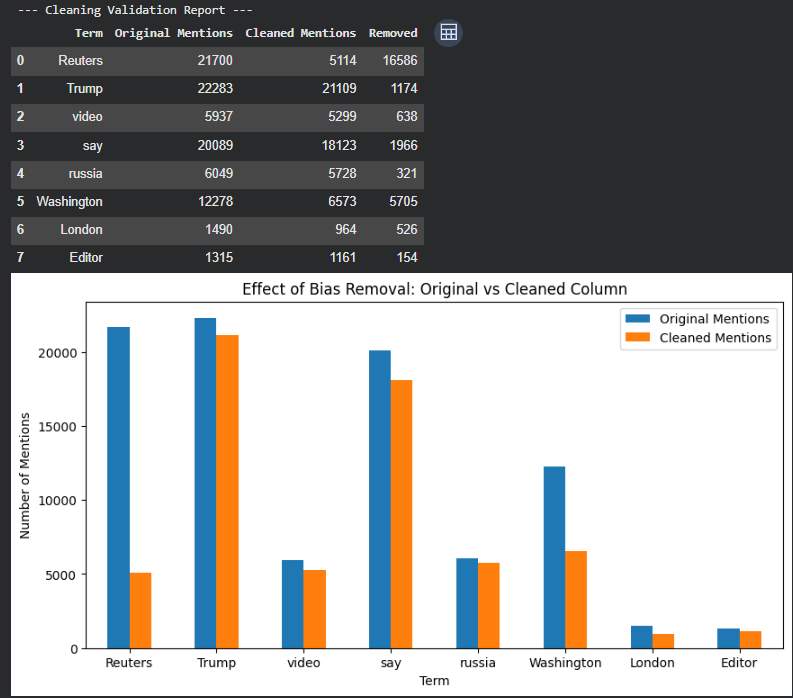

To validate the effectiveness of the bias removal process, a comparative analysis was performed between the raw text and the cleaned text. Results show a drastic reduction in agency-related tokens such as 'Reuters' and geographical datelines like 'Washington'. By eliminating these structural 'anchors' from the beginning of the articles, we ensure the BERT model is forced to analyze the semantic content of the news rather than identifying simple source signatures. This step is crucial to mitigate data leakage and improve the model's ability to generalize to unseen datasets from 2026

# Conclusion
The analysis of the ISOT dataset reveals a high dependency on specific structural patterns, such as the consistent length of Reuters articles and the presence of recurring agency datelines. While these features allow for high training accuracy, they also represent a significant overfitting risk, as the model might learn to identify the source signature rather than the content credibility.

 To mitigate these biases and improve the system's ability to generalize to modern 2026 misinformation, we will proceed to fuse the ISOT and WELFake datasets. This ensemble approach aims to dilute source-specific watermarks while exposing the BERT model to a more diverse range of linguistic styles, topics, and formats, ultimately creating a more robust and reliable detection tool.